In [1]:
#必要なパッケージのインポート、インストール
!pip install numpy==1.25
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
!pip install pytorch_lightning==1.9.4
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.loggers import CSVLogger

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.8/827.8 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 56.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitl

In [2]:
 #必要なパッケージのインストール、インポート
 !pip install -q torchmetrics==0.11.4
 import torchmetrics
 from torchmetrics.functional import accuracy
 import torchvision
 from torchvision import transforms
 from torchvision.datasets import ImageFolder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 31.5 MB/s eta 0:00:00


In [3]:
#Googleドライブにアクセス
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#学習時のみデータ拡張を適用する。学習済モデルに合わせた前処理を追加
transform_train = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
#検証時とテスト時はデータ拡張なし。学習済モデルに合わせた前処理を追加
transform_valtest = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
#前処理とアノテーション（ラベル付け）
dataset = ImageFolder('/content/drive/MyDrive/medical_folders', transform_train)
dataset

Dataset ImageFolder
    Number of datapoints: 204
    Root location: /content/drive/MyDrive/medical_folders
    StandardTransform
Transform: Compose(
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               RandomHorizontalFlip(p=0.5)
               RandomVerticalFlip(p=0.5)
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [ ]:
#trainとvalのサンプルサイズの設定
n_train = int(len(dataset) * 0.7)
n_val = int(len(dataset) * 0.1)
n_test = len(dataset) - n_train - n_val

In [ ]:
#trainとvalとtestに分割
pl.seed_everything(0)
train, val, test = torch.utils.data.random_split(dataset, [n_train, n_val, n_test])

INFO:lightning_fabric.utilities.seed:Global seed set to 0


In [ ]:
#検証およびテストデータセットの変換をデータ拡張をしないものに変更する
val.dataset.transform = transform_valtest
test.dataset.transform = transform_valtest

In [ ]:
#バッチサイズの設定
batch_size = 5

In [ ]:
#Data Loaderの定義
train_loader = torch.utils.data.DataLoader(train, batch_size, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val, batch_size)
test_loader = torch.utils.data.DataLoader(test, batch_size)

In [ ]:
#学習済みネットワークの利用
from torchvision.models import densenet201

In [ ]:
#densenetを特徴抽出器として利用
feature = densenet201(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
#ネットワークの定義
class Net(pl.LightningModule):

    def __init__(self):
        super().__init__()

        self.feature = densenet201(pretrained=True)
        self.fc = nn.Linear(1000, 5)

    def forward(self, x):
        h = self.feature(x)
        h = self.fc(h)
        return h

    def training_step(self, batch, batch_idx):
        x, t = batch
        y = self(x)
        loss = F.cross_entropy(y, t)
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.log('train_acc', accuracy(y.softmax(dim=-1), t, task='multiclass', num_classes=5, top_k=1), on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, t = batch
        y = self(x)
        loss = F.cross_entropy(y, t)
        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.log('val_acc', accuracy(y.softmax(dim=-1), t, task='multiclass', num_classes=5, top_k=1), on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, t = batch
        y = self(x)
        loss = F.cross_entropy(y, t)
        self.log('test_loss', loss, on_step=False, on_epoch=True)
        self.log('test_acc', accuracy(y.softmax(dim=-1), t, task='multiclass', num_classes=5, top_k=1), on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=0.007)
        return optimizer

In [ ]:
#学習の実行
pl.seed_everything(0)
net = Net()
logger = CSVLogger(save_dir='logs', name=' my_exp')
trainer = pl.Trainer(max_epochs=50, deterministic=False, logger=logger)
trainer.fit(net, train_loader, val_loader)

INFO:lightning_fabric.utilities.seed:Global seed set to 0
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/setup.py:176: PossibleUserWarning: GPU available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='gpu', devices=1)`.
  rank_zero_warn(
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type     | Params
-------------------------------------
0 | feature | DenseNet | 20.0 M
1 | fc      | Linear   | 5.0 K 
-------------------------------------
20.0 M    Trainable params
0         Non-trainable params
20.0 M    Total params
80.076    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower 

Training: 0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


In [ ]:
#テストデータで検証
results = trainer.test(dataloaders=test_loader)

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:124: UserWarning: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
  rank_zero_warn(
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/ my_exp/version_1/checkpoints/epoch=49-step=1400.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from checkpoint at logs/ my_exp/version_1/checkpoints/epoch=49-step=1400.ckpt
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, test_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of

Testing: 0it [00:00, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Runningstage.testing    ┃                           ┃
┃          metric           ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8333333134651184     │
│         test_loss         │    0.8069827556610107     │
└───────────────────────────┴───────────────────────────┘

In [ ]:
#学習時のログをpandasで読み込む
log = pd.read_csv('/content/logs/ my_exp/version_1/metrics.csv')

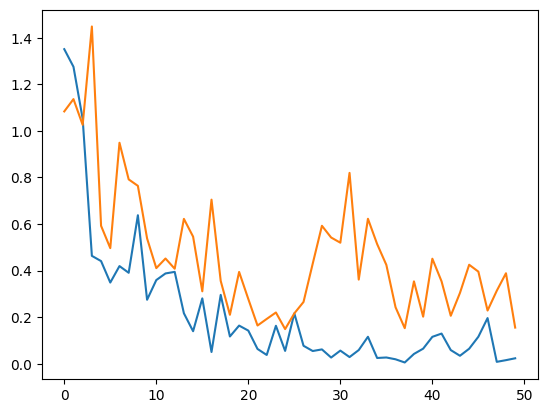

In [ ]:
#lossのグラフ
log[['train_loss', 'epoch']].dropna(how='any', axis=0).reset_index()['train_loss'].plot();
log[['val_loss', 'epoch']].dropna(how='any', axis=0).reset_index()['val_loss'].plot();

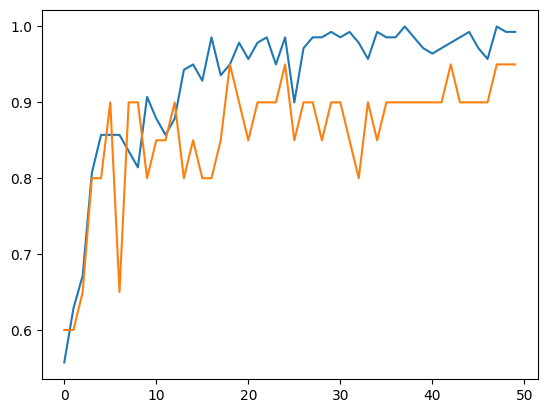

In [ ]:
#accuracyのグラフ
log[['train_acc', 'epoch']].dropna(how='any', axis=0).reset_index()['train_acc'].plot();
log[['val_acc', 'epoch']].dropna(how='any', axis=0).reset_index()['val_acc'].plot();

In [ ]:
#モデルの重み
net.state_dict()

OrderedDict([('feature.features.conv0.weight',
              tensor([[[[ 1.3524e-02,  2.3285e-02, -1.6485e-03,  ..., -1.5713e-02,
                         -1.0251e-02, -1.5230e-03],
                        [-2.0952e-02, -5.6102e-02, -6.2789e-02,  ..., -9.9514e-02,
                         -8.0437e-02, -4.6410e-02],
                        [ 1.8897e-02,  2.9552e-02,  1.3300e-02,  ...,  1.0316e-01,
                          6.6770e-02,  4.9729e-02],
                        ...,
                        [-3.8540e-02, -9.5193e-02, -2.1015e-01,  ..., -4.1286e-01,
                         -2.9844e-01, -1.3448e-01],
                        [-4.4353e-02, -7.4292e-02, -8.7390e-02,  ..., -3.5819e-02,
                         -2.4671e-02, -5.7707e-02],
                        [ 9.2057e-03,  2.4629e-02,  6.0539e-02,  ...,  7.7945e-02,
                          5.7981e-02,  1.5110e-02]],
              
                       [[ 1.1478e-02,  2.5336e-02, -3.5939e-03,  ..., -2.4874e-02,
               

In [ ]:
#学習済モデルを保存
torch.save(net.state_dict(), 'image_densenet201c.pt')

In [ ]:
#推論時に必要なパッケージのインポート、インストール
import torch
import torch.nn as nn
!pip install pytorch_lightning==1.9.4
import pytorch_lightning as pl
from torchvision import transforms
from torchvision.models import densenet201
from PIL import Image

In [ ]:
#推論用のネットワークの定義
class Net2(pl.LightningModule):

    def __init__(self):
        super().__init__()

        self.feature = densenet201(pretrained=True)
        self.fc = nn.Linear(1000, 5)

    def forward(self, x):
        h = self.feature(x)
        h = self.fc(h)
        return h

In [ ]:
#推論モードでインスタンス化
net2 = Net2().cpu().eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#学習済モデルの重みを読み込む
net2.load_state_dict(torch.load('/content/drive/MyDrive/image_densenet201c.pt', map_location=torch.device('cpu')))

<All keys matched successfully>

In [ ]:
#推論する関数の作成
def predict2(path):
    img = Image.open(path)
    img = transform_valtest(img)
    img = img.unsqueeze(0)
    with torch.no_grad():
        y = net2(img)
    return y.softmax(dim=-1)

In [ ]:
#一つの画像の推論結果
predict2('/content/drive/MyDrive/transformed_images/label0c/aug_0.jpg')

tensor([[9.9999e-01, 1.2802e-09, 1.3303e-08, 6.7170e-10, 8.4573e-06]])